# FREM decoding results: per-category weight maps + AUC

`FREMClassifier` (Fast Regularized Ensemble of Models) fit per subject on GLMsingle type-D
betas, 4-class stimulus category (face / figure / hand / house), leave-one-run-out CV,
`scoring='roc_auc'`. Complementary to the searchlight:

- **searchlight** → *where a category can be locally decoded* (accuracy/recall map).
- **FREM** → *which voxels the global model relies on to identify a category* (weight map),
  plus per-class **ROC-AUC** (chance 0.5).

**Caveat (carried throughout):** FREM `coef_img_` weight maps are **discriminative
coefficients, not response maps**. A high weight means the model uses that voxel to separate
classes — not that the voxel responds to the category. Weights are only meaningful jointly
(multivariate) and, for neuroscientific interpretation, should be Haufe-transformed
(Haufe et al., 2014; see Section 3). Treat the weight maps as qualitative; the **per-class
AUC** is the quantitative measure.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from scipy import stats
from nilearn import image, plotting, datasets

sys.path.insert(0, str(Path('../')))
try:
    from utils.data import load_participant_list
except Exception:
    load_participant_list = None

# --- Auto-detect where the derivatives live (VM mount, else local sync) ---
_DERIV_CANDIDATES = [
    Path('/mnt/data/learning-habits/bids_dataset/derivatives'),                          # uzh.vm
    Path.home() / 'phd_local/data/LearningHabits/dev_sample/bids_dataset/derivatives',   # local Mac sync
]
DERIVATIVES_DIR = next((p for p in _DERIV_CANDIDATES if p.exists()), _DERIV_CANDIDATES[0])
print(f'DERIVATIVES_DIR = {DERIVATIVES_DIR}')
# --------------------------------------------------------------------------

FREM_DIR = DERIVATIVES_DIR / 'frem'
SL_V2    = DERIVATIVES_DIR / 'searchlight_recall'   # for Section 4 cross-reference (optional)
VC_MASK_PATH = DERIVATIVES_DIR / 'decoding' / 'visual_cortex_mask.nii.gz'
PARTICIPANTS_FILE = DERIVATIVES_DIR.parent.parent / 'participants_mvpa.tsv'

STIM_CATS = ['face', 'figure', 'hand', 'house']
CHANCE_AUC = 0.5

def coef_path(sub, cat):
    return FREM_DIR / f'sub-{sub}' / f'sub-{sub}_frem_coef_{cat}.nii.gz'
def scores_path(sub):
    return FREM_DIR / f'sub-{sub}' / f'sub-{sub}_frem_cvscores.csv'

if load_participant_list is not None and PARTICIPANTS_FILE.exists():
    subjects = load_participant_list(PARTICIPANTS_FILE.parent, file_name=PARTICIPANTS_FILE.name)
else:
    subjects = sorted(p.name[4:] for p in FREM_DIR.glob('sub-*') if p.is_dir())

subs = [s for s in subjects
        if scores_path(s).exists() and all(coef_path(s, c).exists() for c in STIM_CATS)]
print(f'Subjects with complete FREM outputs: {len(subs)} / {len(subjects)}')
missing = [s for s in subjects if s not in subs]
if missing:
    print(f'Incomplete/missing: {missing}')

DERIVATIVES_DIR = /mnt/data/learning-habits/bids_dataset/derivatives
Subjects with complete FREM outputs: 59 / 59


## 1. Per-class ROC-AUC (the quantitative measure)

Cross-validated one-vs-rest AUC per category (chance 0.5), from `*_frem_cvscores.csv`. This
is the clean, imbalance-robust per-category decodability number — the headline quantitative
result. Bars are group mean ± SEM of per-subject mean AUC; stars are one-sample t vs 0.5.

       face  figure   hand  house
mean  0.597   0.680  0.585  0.603
std   0.068   0.078  0.082  0.079
min   0.438   0.541  0.444  0.477
max   0.783   0.870  0.833  0.876


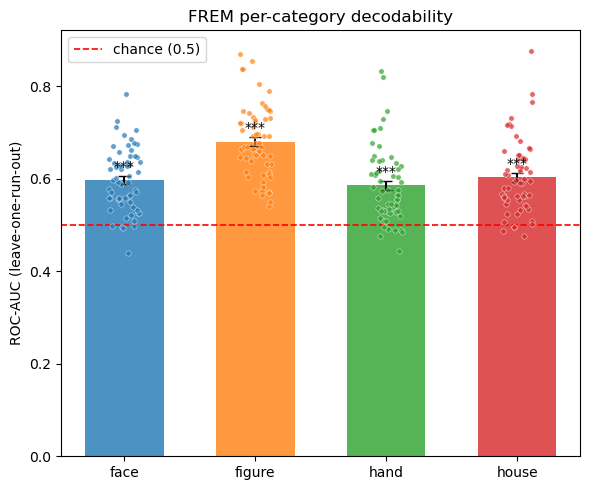

In [2]:
# Collect per-subject mean AUC per category
recs = []
for s in subs:
    df = pd.read_csv(scores_path(s)).set_index('category')
    recs.append({'subject': s, **{c: df.loc[c, 'mean_auc'] for c in STIM_CATS}})
auc = pd.DataFrame(recs).set_index('subject')
print(auc.describe().loc[['mean', 'std', 'min', 'max']].round(3))

def star(p):
    return '***' if p < 1e-3 else '**' if p < 1e-2 else '*' if p < 5e-2 else 'ns'

fig, ax = plt.subplots(figsize=(6, 5))
x = np.arange(len(STIM_CATS)); rng = np.random.default_rng(0)
colors = [plt.cm.tab10(i) for i in range(len(STIM_CATS))]
for i, c in enumerate(STIM_CATS):
    vals = auc[c].values
    sem = vals.std() / np.sqrt(len(vals))
    ax.bar(i, vals.mean(), 0.6, yerr=sem, capsize=4, color=colors[i], alpha=0.8, zorder=2)
    ax.scatter(i + rng.uniform(-0.12, 0.12, len(vals)), vals, s=15,
               color=colors[i], edgecolors='white', linewidth=0.4, alpha=0.7, zorder=3)
    _, p = stats.ttest_1samp(vals, CHANCE_AUC)
    ax.text(i, vals.mean() + sem + 0.01, star(p), ha='center', fontsize=10)
ax.axhline(CHANCE_AUC, color='red', ls='--', lw=1.2, label='chance (0.5)')
ax.set_xticks(x); ax.set_xticklabels(STIM_CATS)
ax.set_ylabel('ROC-AUC (leave-one-run-out)')
ax.set_title('FREM per-category decodability')
ax.legend(); plt.tight_layout(); plt.show()

## 2. Per-category group-mean weight maps (qualitative)

Group average of `coef_img_[cat]` across subjects. Shown on a symmetric diverging scale.
**Interpret with care** (see caveat above): these are discriminative weights, not response
maps; positive vs negative weight is only meaningful jointly. Group-averaging assumes
sign-consistency of weights across subjects, which FREM's ensembling + regularization
encourages but does not guarantee — read these as *qualitative* localization, cross-checked
against the AUC (Sec 1) and the searchlight recall maps (Sec 4).

shared |weight| cap (99.5th pct): 0.00169


/tmp/ipykernel_57855/1834280088.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


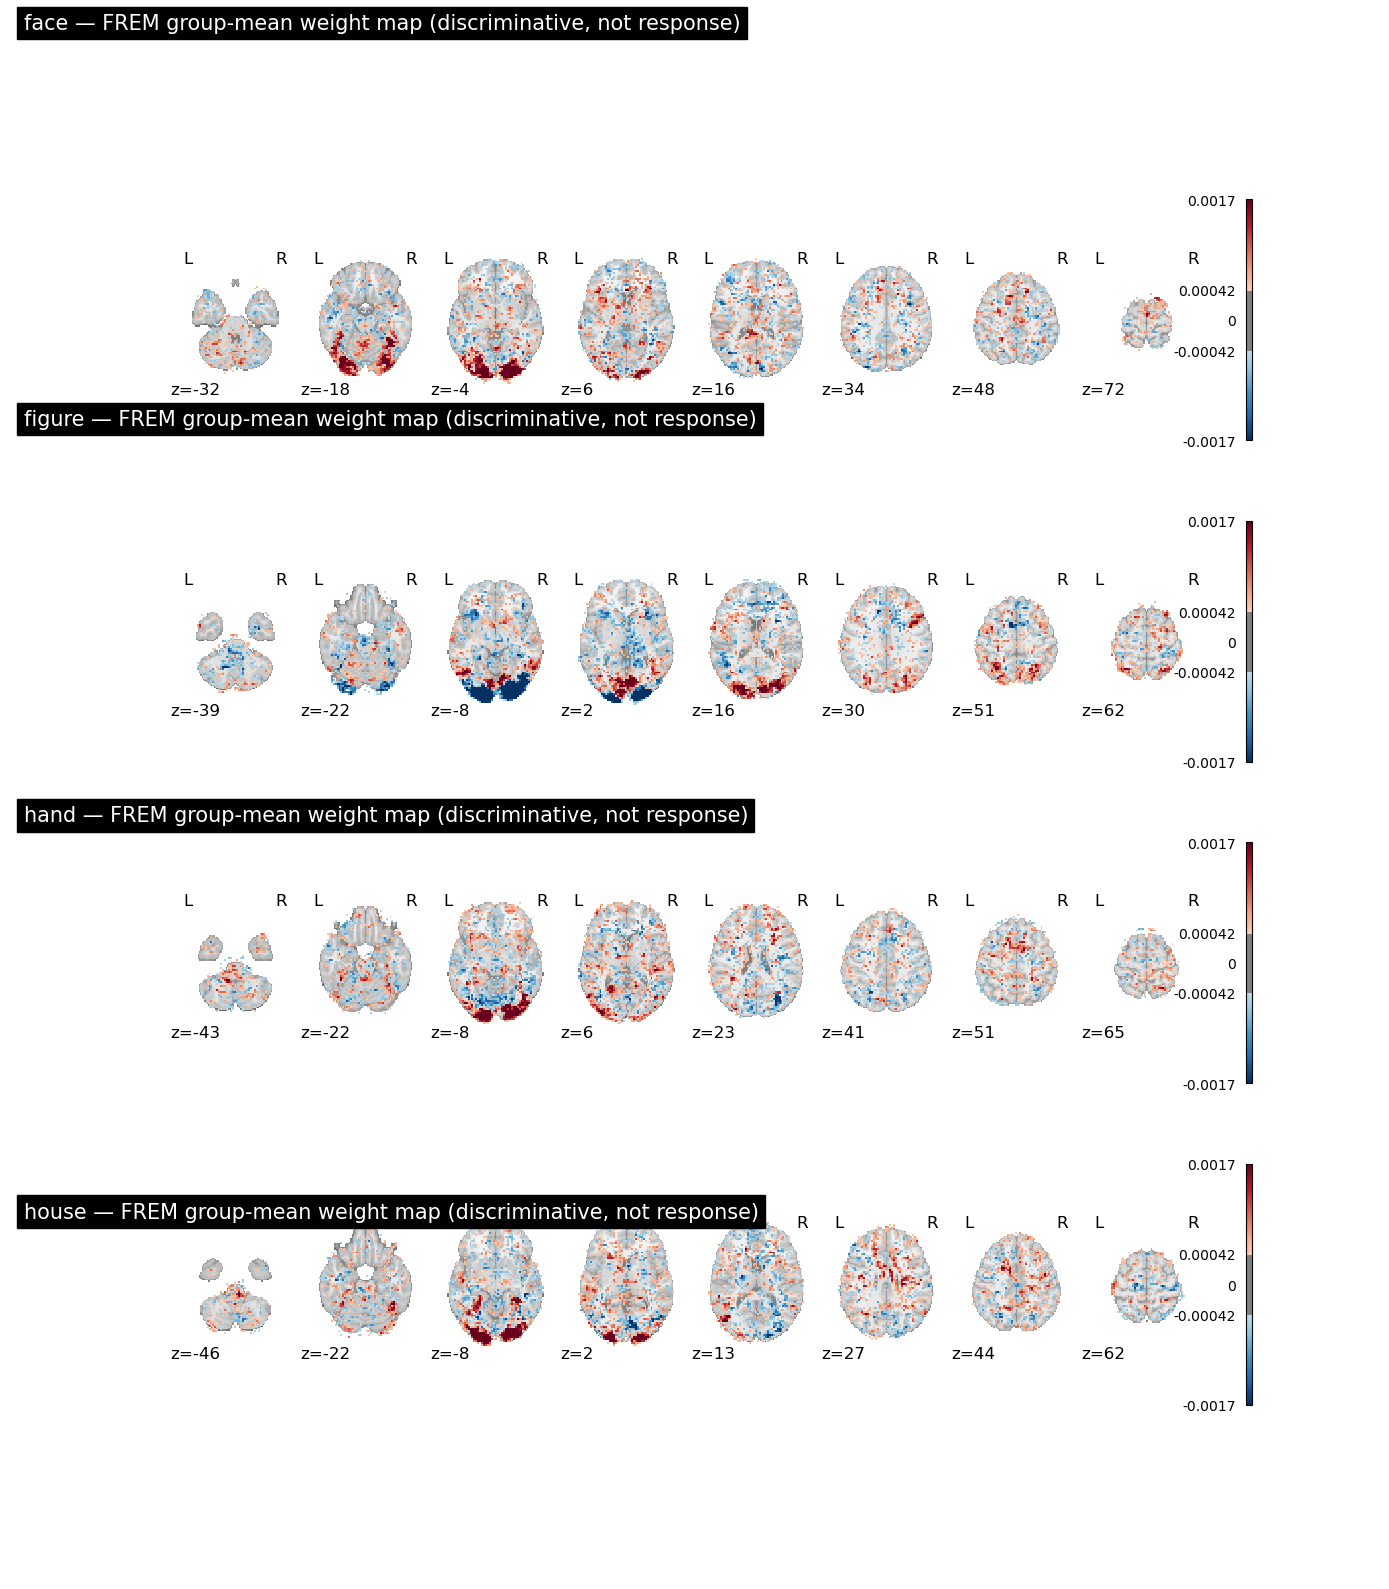

In [3]:
def load_4d(paths):
    imgs, bad, ref = [], [], None
    for p in paths:
        img = nib.load(p)
        if ref is None:
            ref = (img.affine, img.shape[:3])
        if img.shape[:3] != ref[1] or not np.allclose(img.affine, ref[0], atol=1e-3):
            bad.append(Path(p).parent.name); continue
        imgs.append(img)
    if bad:
        print(f'  WARNING: {len(bad)} off-grid, skipped: {bad}')
    return image.concat_imgs(imgs)

coef_4d = {c: load_4d([coef_path(s, c) for s in subs]) for c in STIM_CATS}
coef_mean = {c: image.mean_img(coef_4d[c]) for c in STIM_CATS}

# Shared symmetric scale across categories
vmax = np.percentile(np.abs(np.concatenate(
    [coef_mean[c].get_fdata().ravel() for c in STIM_CATS])), 99.5)
print(f'shared |weight| cap (99.5th pct): {vmax:.3g}')

fig, axes = plt.subplots(len(STIM_CATS), 1, figsize=(14, 4 * len(STIM_CATS)))
for ax, c in zip(axes, STIM_CATS):
    plotting.plot_stat_map(coef_mean[c], threshold=vmax * 0.25, colorbar=True,
        title=f'{c} — FREM group-mean weight map (discriminative, not response)',
        display_mode='z', cut_coords=8, axes=ax,
        cmap='RdBu_r', symmetric_cbar=True, vmax=vmax)
plt.tight_layout(); plt.show()

## 3. Haufe-transformed pattern maps (enhancement — not yet computed)

The weight maps in Section 2 are **backward (decoding) models**. To interpret them
neuroscientifically they should be converted to **forward (encoding) patterns** via the
Haufe transform (Haufe et al., 2014, *NeuroImage*):

$$A = \Sigma_X\, W\, \Sigma_{\hat{s}}^{-1}$$

where $\Sigma_X$ is the covariance of the (masked, standardized) beta patterns, $W$ the
decoder weights, and $\hat{s}$ the decision scores. Pattern maps $A$ are directly
interpretable (high $A$ ⇒ the category actually drives that voxel's signal), unlike raw
weights which can be large in signal-free suppressor voxels.

**Why it's not computed here:** the transform needs the per-subject data matrix $X$ and the
decision scores $\hat{s}$, which `run_frem.py` does not currently persist. Computing it
would require a small extension to `run_frem.py` to save, per subject, the masked beta
matrix (or its covariance) and `decision_function` outputs, then applying the formula per
class. Flagged as a follow-up if the weight maps prove worth interpreting quantitatively.

## 4. Cross-reference: FREM weights vs searchlight recall (qualitative)

Side-by-side of the FREM group-mean weight map (left) and the v2 searchlight per-class
recall group-mean map (right) for each category. They answer **different questions** (global
discriminative weight vs local decodability), so this is a qualitative check of spatial
convergence, not a quantitative comparison. Each panel on its own scale. Skipped
automatically if the v2 searchlight (`searchlight_recall/`) is not present.

Cross-referencing on 59 subjects with both FREM and v2 recall maps


/tmp/ipykernel_57855/3134020798.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


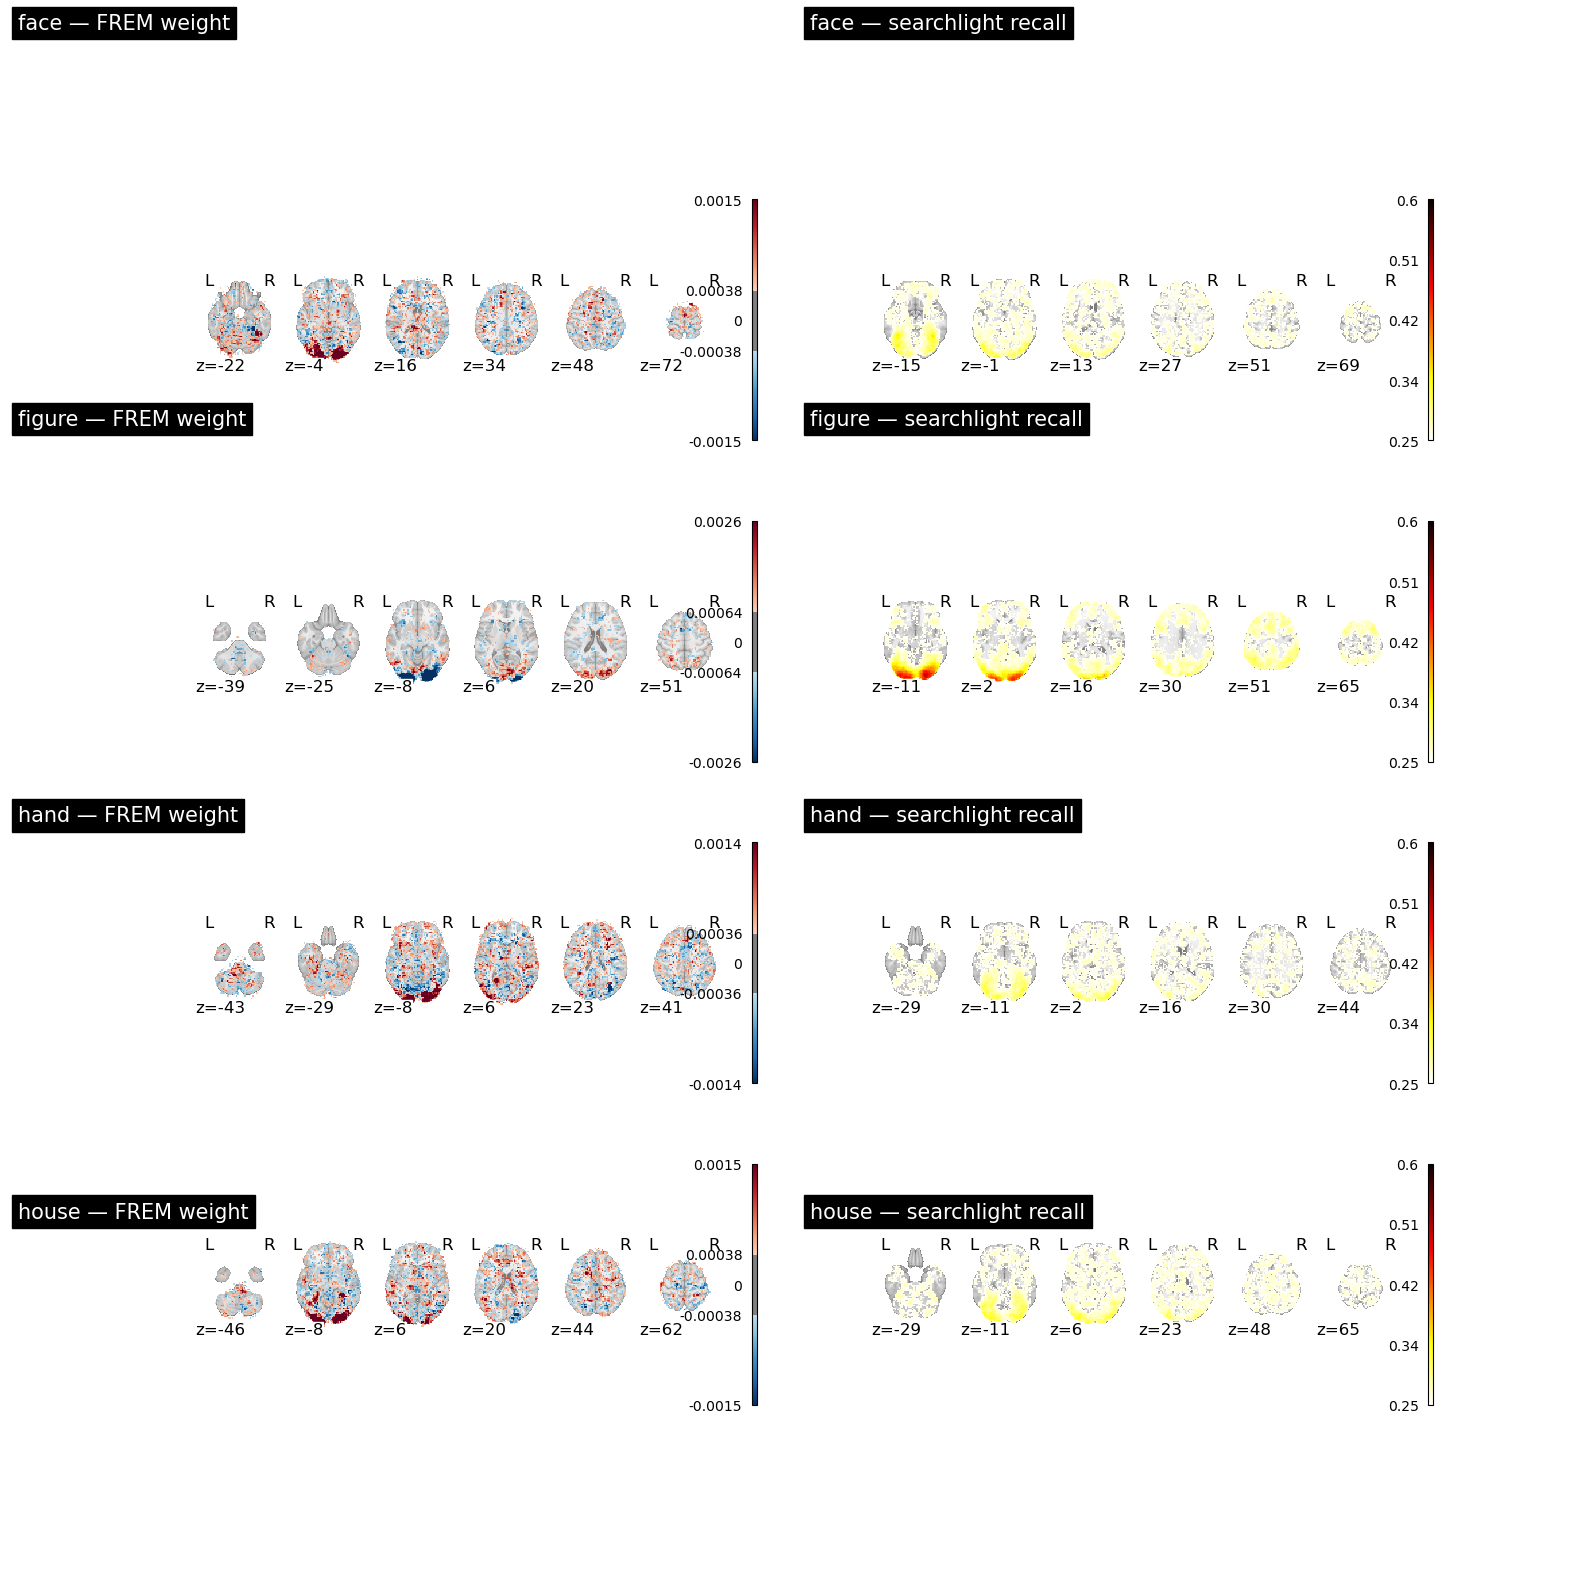

In [4]:
def v2_recall_path(sub, cat):
    return SL_V2 / f'sub-{sub}' / f'sub-{sub}_searchlight_stim_cat_recall_{cat}.nii.gz'

v2_subs = [s for s in subs if all(v2_recall_path(s, c).exists() for c in STIM_CATS)]
if not v2_subs:
    print('v2 searchlight recall maps not found — skipping cross-reference. '
          'Run the v2 searchlight, then re-run this cell.')
else:
    print(f'Cross-referencing on {len(v2_subs)} subjects with both FREM and v2 recall maps')
    rec_mean = {c: image.mean_img(load_4d([v2_recall_path(s, c) for s in v2_subs]))
                for c in STIM_CATS}
    fig, axes = plt.subplots(len(STIM_CATS), 2, figsize=(16, 4 * len(STIM_CATS)))
    for row, c in enumerate(STIM_CATS):
        wmax = np.percentile(np.abs(coef_mean[c].get_fdata().ravel()), 99.5)
        plotting.plot_stat_map(coef_mean[c], threshold=wmax * 0.25, colorbar=True,
            title=f'{c} — FREM weight', display_mode='z', cut_coords=6,
            axes=axes[row, 0], cmap='RdBu_r', symmetric_cbar=True, vmax=wmax)
        plotting.plot_stat_map(rec_mean[c], threshold=0.25, colorbar=True,
            title=f'{c} — searchlight recall', display_mode='z', cut_coords=6,
            axes=axes[row, 1], cmap='hot_r', vmin=0.25, vmax=0.60)
    plt.tight_layout(); plt.show()

## 5. Findings summary

_(Fill in after running against the full cohort.)_

- **Decodability (Sec 1):** which categories are significantly above chance (AUC > 0.5), and
  the ordering (expect house/face high, hand lower — matching the sub-01 smoke test).
- **Weight maps (Sec 2):** do the discriminative weights concentrate in plausible
  category-selective cortex? (Qualitative — mind the caveat.)
- **Convergence (Sec 4):** do FREM weights and searchlight recall highlight overlapping
  regions per category, despite answering different questions? Convergence strengthens the
  spatial-specificity claim.
- **Bottom line:** FREM adds a fast, chance-referenced (AUC) per-category decodability
  measure and a complementary weight map to the searchlight's local decodability maps.